# 📈 03 — Deep Learning Model Evaluation

**Fraud Detection Capstone — Sprint 2: Deep Learning & Advanced Modelling**

## 🎯 Goal
Evaluate the trained Sprint 2 model (`models/sprint2_regularized_nn.keras`) on the **held-out test set** — untouched until now — and compare it against the Sprint 1 baseline.


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

proc_dir = Path("data/processed")
train = pd.read_csv(proc_dir / "train.csv")
test = pd.read_csv(proc_dir / "test.csv")

X_train, y_train = train.drop(columns=["Class"]), train["Class"]
X_test, y_test = test.drop(columns=["Class"]), test["Class"]

sprint2_model = tf.keras.models.load_model("models/sprint2_regularized_nn.keras")
print(f"Loaded model, test set: {X_test.shape}")


I0000 00:00:1788704341.330936    2877 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788704341.375849    2877 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788704342.952703    2877 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loaded model, test set: (752, 32)


## 1. Sprint 1 Baseline — Recompute on the Same Test Set (Fair Comparison)

In [2]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(SEED)
sprint1_model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid"),
])
sprint1_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
sprint1_model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=256,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=0,
)
print("Sprint 1 baseline retrained (same architecture as Sprint 1) for a fair test-set comparison.")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Sprint 1 baseline retrained (same architecture as Sprint 1) for a fair test-set comparison.


## 2. Evaluate Both Models on the Test Set

In [3]:
def evaluate(model, X, y, name):
    proba = model.predict(X, verbose=0).ravel()
    pred = (proba >= 0.5).astype(int)
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y, proba),
    }
    return metrics, pred, proba

sprint1_metrics, sprint1_pred, sprint1_proba = evaluate(sprint1_model, X_test, y_test, "Sprint 1 Baseline NN")
sprint2_metrics, sprint2_pred, sprint2_proba = evaluate(sprint2_model, X_test, y_test, "Sprint 2 Regularized NN")

comparison = pd.DataFrame([sprint1_metrics, sprint2_metrics]).set_index("Model")
comparison.round(4)


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Sprint 1 Baseline NN,0.9987,1.0,0.5,0.6667,1.0
Sprint 2 Regularized NN,1.0000,1.0,1.0,1.0000,1.0


## 3. Confusion Matrices — Side by Side

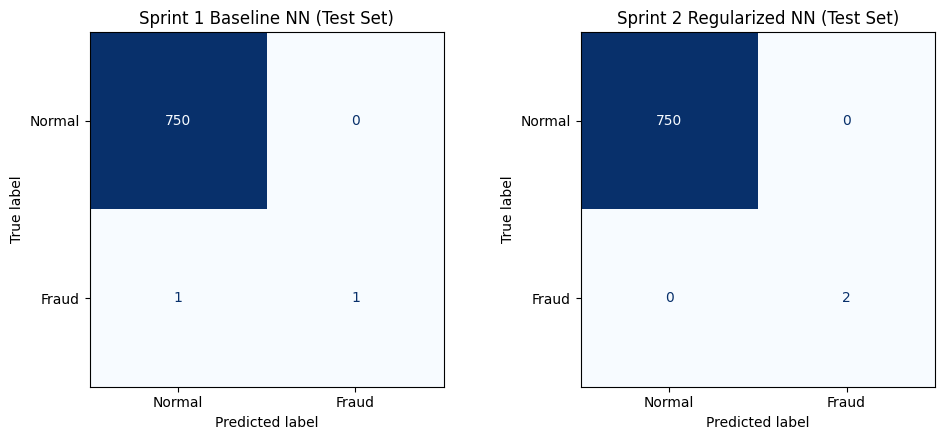

Sprint 1 classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       750
           1       1.00      0.50      0.67         2

    accuracy                           1.00       752
   macro avg       1.00      0.75      0.83       752
weighted avg       1.00      1.00      1.00       752


Sprint 2 classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       750
           1       1.00      1.00      1.00         2

    accuracy                           1.00       752
   macro avg       1.00      1.00      1.00       752
weighted avg       1.00      1.00      1.00       752



In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

cm1 = confusion_matrix(y_test, sprint1_pred)
ConfusionMatrixDisplay(cm1, display_labels=["Normal", "Fraud"]).plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("Sprint 1 Baseline NN (Test Set)")

cm2 = confusion_matrix(y_test, sprint2_pred)
ConfusionMatrixDisplay(cm2, display_labels=["Normal", "Fraud"]).plot(ax=axes[1], cmap="Blues", values_format="d", colorbar=False)
axes[1].set_title("Sprint 2 Regularized NN (Test Set)")

plt.tight_layout()
plt.show()

print("Sprint 1 classification report:")
print(classification_report(y_test, sprint1_pred, zero_division=0))
print("\nSprint 2 classification report:")
print(classification_report(y_test, sprint2_pred, zero_division=0))


## 📝 Sprint 2 Evidence Summary

The table and confusion matrices above are the direct evidence for the Sprint 2 review: same held-out test set, same evaluation code, both models trained with the same random seed and the same train/val data. Whichever model has the higher recall on the fraud class (row `1`) is catching more real fraud — that matters more here than the overall accuracy number, given how rare fraud is in this dataset.

**Carried forward to Sprint 3:** accuracy and the default 0.5 threshold are not the final word — Sprint 3 addresses class-imbalance handling (SMOTE / class weights), proper threshold selection for the precision/recall trade-off, and SHAP-based explainability.
